In [2]:
import random
import requests
import time
import matplotlib.pyplot as plt

In [3]:
NUM_NODES = 10
ROUNDS = 15

nodes = [False] * NUM_NODES
nodes[0] = True

In [4]:
def detect():
    tx = [random.random() for _ in range(30)]

    try:
        res = requests.post(
            "http://127.0.0.1:8000/predict",
            json={"transaction": tx}
        )
        return res.json()["fraud"]
    except:
        return False

In [5]:
def gossip_pull(nodes):
    new_nodes = nodes.copy()

    for i in range(len(nodes)):
        if not nodes[i]:
            target = random.randint(0, len(nodes)-1)

            if nodes[target]:
                new_nodes[i] = True
                print(f"Node {i} PULL ← Node {target}")

    return new_nodes

In [6]:
history = []

for r in range(ROUNDS):
    print(f"\n🔁 Round {r+1}")

    # AI detection
    if detect():
        nodes[0] = True
        print("🚨 AI detected fraud at node 0")

    nodes = gossip_pull(nodes)

    informed = sum(nodes)
    history.append(informed)

    print(f"📊 Informed: {informed}/{NUM_NODES}")

    if informed == NUM_NODES:
        break

    time.sleep(1)


🔁 Round 1
📊 Informed: 1/10

🔁 Round 2
📊 Informed: 1/10

🔁 Round 3
📊 Informed: 1/10

🔁 Round 4
Node 1 PULL ← Node 0
Node 3 PULL ← Node 0
📊 Informed: 3/10

🔁 Round 5
Node 2 PULL ← Node 1
Node 4 PULL ← Node 0
Node 6 PULL ← Node 3
📊 Informed: 6/10

🔁 Round 6
Node 5 PULL ← Node 1
Node 7 PULL ← Node 2
Node 8 PULL ← Node 0
📊 Informed: 9/10

🔁 Round 7
Node 9 PULL ← Node 6
📊 Informed: 10/10


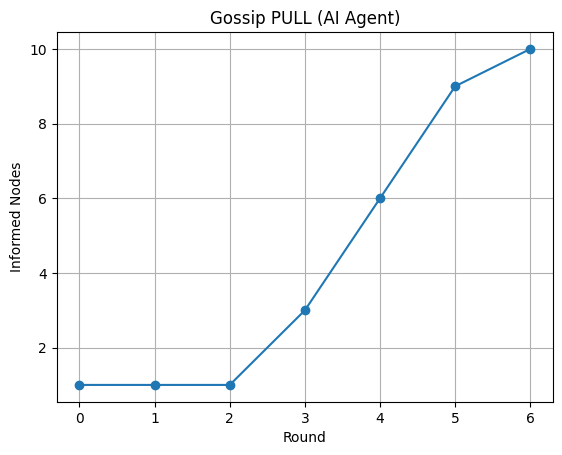

In [7]:
plt.plot(history, marker='o')
plt.title("Gossip PULL (AI Agent)")
plt.xlabel("Round")
plt.ylabel("Informed Nodes")
plt.grid()
plt.show()